In [44]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor, ClassSubsetPreprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
from analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
from analytics.ps2_dataset import SortPreprocessor
from spec.enums import EventType

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
proprocessing_steps = []
link_preprocessing_steps = []
submit_event = EventType.Submit
grades_link_table = "Subject"
grades_col = None
start_time = None
end_time = None
early_percentage = None
assignment_ids = None
compile_error_type_col = Cols.CompileMessageType
compile_event = EventType.Compile
compile_error_event = EventType.CompileError

# Note: Only Fall has compilation data; spring has no Run.Program events!
edwards_s19_config = {
    "config_path": "sample_data_configs/edwards2019.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
        # Make sure this comes last so Fall is correct
        ClassSubsetPreprocessor("Spring"),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2019-02-25 00:00:00",
    "early_percentage": 0.23,
    "assignment_ids": ["p4s", "p5s"],  # Only 2 assignments
    "grades_col": "exam2",
}

edwards_f19_config = edwards_s19_config.copy()
edwards_f19_config["proprocessing_steps"] = edwards_s19_config["proprocessing_steps"].copy()
edwards_f19_config["proprocessing_steps"][-1] = ClassSubsetPreprocessor("Fall")
edwards_f19_config["end_time"] = None
edwards_f19_config["assignment_ids"] = None

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2022-01-01 00:00:00",
    "early_percentage": 0.4,
    "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
    "grades_col": "FinalScore",
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.33,
}

cwo_f19_config = {
    "config_path": "sample_data_configs/cwo_f19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.25,
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
    "main_table_preprocessing_steps": [
        CodeBenchAddParentEventIDs(),
    ],
    "grades_link_table": "CourseSubject",
    "grades_col": "final-grade",
    "start_time": "2024-09-01 00:00:00",
    "early_percentage": 0.28,
    "compile_error_type_col": "ProgramErrorOutput",
    "compile_event": EventType.Submit,
    "compile_error_event": EventType.RunTest,
}

# config = cwo_f19_config
# config = codebench2024_config
# config = edwards2021_config
config = edwards_s19_config
locals().update(config)

In [86]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [87]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for i, step in enumerate(proprocessing_steps):
    dataset.main_table_preprocessors.insert(i, step)
for i, step in enumerate(link_preprocessing_steps):
    dataset.link_table_preprocessors.insert(i, step)

In [ ]:
main_table = dataset.get_main_table()
main_table.head()

c:\Users\twprice\Documents\GitHub\ProgSnap2\src\database\reader\csv_reader.py:20: DtypeWarning: Columns (0,3,6,7,8,11,12,13,14,15,16,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


In [ ]:
main_table.shape

(2330634, 22)

In [ ]:
main_table[Cols.CompileMessageType].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
main_table[problem_id_col].unique()

array(['p4s', 'p5s', 'p6s', 'p7s', 'p8s'], dtype=object)

In [ ]:
bad_assignment_ids = [407610653, 1147927607, 1407437764]
main_table = main_table[~main_table[Cols.AssignmentID].isin(bad_assignment_ids)]

In [ ]:
if start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= start_time]
if end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= end_time]

In [ ]:
if "X-ClassID" in main_table.columns:
    class_counts = main_table["X-ClassID"].value_counts()
    print(class_counts)
    min_count = 1000
    invalid_class_ids = class_counts[class_counts < min_count].index
    print(f"Removing classes with less than {min_count} submissions: {invalid_class_ids}")
    main_table = main_table[~main_table["X-ClassID"].isin(invalid_class_ids) & ~main_table["X-ClassID"].isna()]

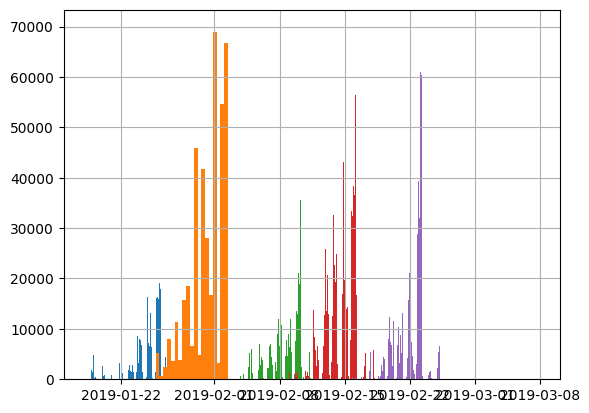

In [ ]:
if "X-ClassID" not in main_table.columns:
    main_table.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
else:
    classes = main_table["X-ClassID"].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table["X-ClassID"] == class_id]
        hist = subset.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        plt.show()

In [ ]:
import numpy as np
for i in main_table[timestamp_col].quantile(np.arange(0, 1.01, 0.01)).to_list():
    print(i)

2019-01-18 04:53:11.918000128+00:00
2019-01-22 16:28:31.549049856+00:00
2019-01-23 20:56:47.206479872+00:00
2019-01-24 03:57:33.052710144+00:00
2019-01-24 22:12:09.830200064+00:00
2019-01-25 04:18:40.519699968+00:00
2019-01-25 18:09:40.618300160+00:00
2019-01-25 21:30:17.052829952+00:00
2019-01-26 00:42:17.920320+00:00
2019-01-26 04:04:30.906220032+00:00
2019-01-26 06:27:45.479599872+00:00
2019-01-27 08:46:42.939929856+00:00
2019-01-28 18:37:05.768719872+00:00
2019-01-29 06:11:30.347620096+00:00
2019-01-29 20:37:47.181860096+00:00
2019-01-30 01:10:25.516649984+00:00
2019-01-30 17:55:07.964600064+00:00
2019-01-30 22:15:16.486710016+00:00
2019-01-31 01:30:15.060920064+00:00
2019-01-31 17:27:01.165839872+00:00
2019-01-31 20:56:17.037999872+00:00
2019-01-31 23:11:38.594220032+00:00
2019-02-01 04:02:20.403379968+00:00
2019-02-01 18:49:56.322160128+00:00
2019-02-01 22:46:41.080120064+00:00
2019-02-02 01:43:50.533750016+00:00
2019-02-02 03:40:19.735919872+00:00
2019-02-02 05:25:08.019609856+0

In [ ]:
#get the data of the third quantile
max = main_table[timestamp_col].max()
min = main_table[timestamp_col].min()
range = max - min
time_cutoff = min + range * early_percentage
print(time_cutoff)
print(main_table[timestamp_col].min())
print(main_table[timestamp_col].max())

data_subset = main_table[main_table[timestamp_col] <= time_cutoff]
print("Assignment IDs:", data_subset[Cols.AssignmentID].unique())
if Cols.ProblemID in data_subset.columns:
    print("Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
print("Percent of logs: ", len(data_subset) / len(main_table) * 100)
print("Percent of assignments: ", len(data_subset[Cols.AssignmentID].unique()) / len(main_table[Cols.AssignmentID].unique()) * 100)
if Cols.ProblemID in main_table.columns:
    print("Percent of problems: ", len(data_subset[Cols.ProblemID].unique()) / len(main_table[Cols.ProblemID].unique()) * 100)
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

2019-01-29 08:33:11.906870+00:00
2019-01-18 04:53:11.918000+00:00
2019-03-07 16:39:17.087000+00:00
Assignment IDs: ['p4s' 'p5s']
Total number of rows: 308116
Percent of logs:  13.220265387014866
Percent of assignments:  40.0


In [ ]:
if assignment_ids is not None:
    data_subset = data_subset[data_subset[Cols.AssignmentID].isin(assignment_ids)]

In [ ]:
testing_student_subset = data_subset[Cols.SubjectID].unique()[:50]
testing_mt_subset = data_subset[data_subset[Cols.SubjectID].isin(testing_student_subset)]

In [ ]:
grouping_cols = ["X-ClassID", Cols.SubjectID, problem_id_col]
grouping_cols = [col for col in grouping_cols if col in main_table.columns]

In [ ]:
main_table.EventType[~main_table[compile_error_type_col].isna()].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
# TODO: Edwards 2019 Spring is missing compile error types...
main_table[compile_error_type_col].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
from analytics.metrics.errors import ErrorMetrics


error_metrics = ErrorMetrics(True,
                             compile_message_type_column=compile_error_type_col,
                             compile_event=compile_event,
                             compile_error_event=compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

C:\Users\twprice\AppData\Local\Temp\ipykernel_3732\4122987523.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)


ErrorQuotient  RepeatedErrorDensity  \
SubjectID AssignmentID                                        
S001      p4s                     0.0                   0.0   
S006      p4s                     0.0                   0.0   
          p5s                     0.0                   0.0   
S007      p4s                     0.0                   0.0   
S008      p4s                     0.0                   0.0   

                        FailedCompileCount  
SubjectID AssignmentID                      
S001      p4s                          0.0  
S006      p4s                          0.0  
          p5s                          0.0  
S007      p4s                          0.0  
S008      p4s                          0.0

In [ ]:
# Investigating a single Edwards 2021 student to see why EQ/RED are so low
# Errors tend not to be repeated and there are many successful runs
# data_subset[
#     (data_subset[Cols.SubjectID] == "Student1") &
#     (data_subset[Cols.AssignmentID] == "Assign7") &
#     ((data_subset[Cols.EventType] == EventType.CompileError) | (data_subset[Cols.EventType] == EventType.RunProgram))
# ].head(40)

In [ ]:
# EQ is very low for codebench because most runs have no errors
# It's interesting/odd that EQ and RED don't correlate on this dataset

error_results.describe()

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
count,205.0,205.0,213.0
mean,0.0,0.0,0.0
std,0.0,0.0,0.0
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0
max,0.0,0.0,0.0


In [ ]:
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
ErrorQuotient,NaN,NaN,NaN
RepeatedErrorDensity,NaN,NaN,NaN
FailedCompileCount,NaN,NaN,NaN


<Axes: ylabel='Frequency'>

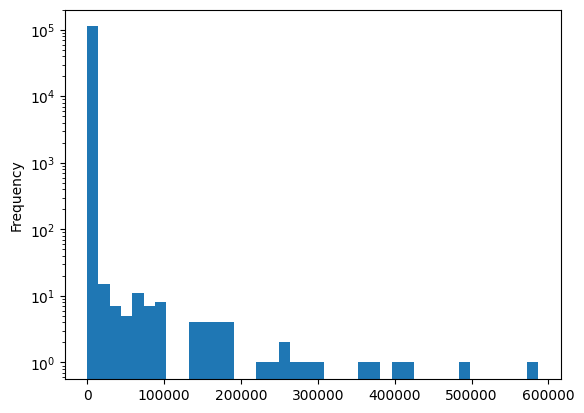

In [ ]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(testing_mt_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [ ]:
TimeMetrics.get_positive_diff_quantiles(data_subset, timestamp_col, grouping_cols) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00       0.000017
0.25       0.002133
0.50       0.003417
0.75       0.010650
0.80       0.014250
0.85       0.020700
0.90       0.034567
0.95       0.083217
0.96       0.114993
0.97       0.171740
0.98       0.291499
0.99       0.620488
1.00    9776.621900
Name: DeltaSeconds, dtype: float64

In [ ]:
from analytics.metrics.time import TimeMetrics

time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_3732\3223447471.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  TotalTime  \
SubjectID AssignmentID                                       
S001      p4s               99.329      243.951    343.280   
S006      p4s             1062.527     1146.275   2208.802   
          p5s              784.848      375.451   1160.299   
S007      p4s               43.417      163.003    206.420   
S008      p4s               75.305       40.195    115.500   
...                            ...          ...        ...   
S503      p5s             2220.860     1445.410   3666.270   
S506      p4s               81.204      117.159    198.363   
          p5s                1.702        0.000      1.702   
S511      p4s             1289.885      693.620   1983.505   
S516      p4s              137.206      176.091    313.297   

                        ActiveTimeAfterCorrect  #Breaks  \
SubjectID AssignmentID                                    
S001      p4s                              0.0        1   
S006      p4s                              0.0        2   
          p5s                              0.0        1   
S007      p4s                              0.0        2   
S008      p4s                              0.0        1   
...                                        ...      ...   
S503      p5s                              0.0        2   
S506      p4s                              0.0        0   
          p5s                              0.0        0   
S511      p4s                              0.0        3   
S516      p4s                              0.0        1   

                                              StartTime  \
SubjectID AssignmentID                                    
S001      p4s          2019-01-25 19:26:44.182000+00:00   
S006      p4s          2019-01-24 00:26:58.549000+00:00   
          p5s          2019-01-29 00:08:18.072000+00:00   
S007      p4s          2019-01-24 05:00:46.486000+00:00   
S008      p4s          2019-01-18 17:09:07.644000+00:00   
...                                                 ...   
S503      p5s          2019-01-29 05:21:16.799000+00:00   
S506      p4s          2019-01-25 17:30:21.775000+00:00   
          p5s          2019-01-28 18:05:46.765000+00:00   
S511      p4s          2019-01-24 21:14:21.967000+00:00   
S516      p4s          2019-01-25 23:11:04.366000+00:00   

                                       FirstCorrectTime  \
SubjectID AssignmentID                                    
S001      p4s          2019-01-25 20:12:38.547000+00:00   
S006      p4s          2019-01-24 01:40:48.993000+00:00   
          p5s                                       NaT   
S007      p4s          2019-01-24 17:19:33.430000+00:00   
S008      p4s          2019-01-18 17:52:55.776000+00:00   
...                                                 ...   
S503      p5s                                       NaT   
S506      p4s          2019-01-25 17:33:40.138000+00:00   
          p5s                                       NaT   
S511      p4s          2019-01-25 04:55:45.114000+00:00   
S516      p4s          2019-01-26 00:21:51.209000+00:00   

                                                EndTime  
SubjectID AssignmentID                                   
S001      p4s          2019-01-25 20:12:38.547000+00:00  
S006      p4s          2019-01-24 01:40:48.993000+00:00  
          p5s          2019-01-29 00:31:32.248000+00:00  
S007      p4s          2019-01-24 17:19:33.430000+00:00  
S008      p4s          2019-01-18 17:52:55.776000+00:00  
...                                                 ...  
S503      p5s          2019-01-29 06:31:37.029000+00:00  
S506      p4s          2019-01-25 17:33:40.138000+00:00  
          p5s          2019-01-28 18:05:48.467000+00:00  
S511      p4s          2019-01-25 04:55:45.114000+00:00  
S516      p4s          2019-01-26 00:21:51.209000+00:00  

[213 rows x 8 columns]

In [ ]:
result.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks
count,213.000000,213.000000,213.000000,213.0,213.000000
mean,1339.737845,925.605033,2265.342878,0.0,3.507042
std,1437.110861,1030.163869,2396.082568,0.0,4.394057
min,0.000000,0.000000,0.000000,0.0,0.000000
25%,352.791000,220.572000,634.862000,0.0,1.000000
50%,894.097000,613.356000,1471.216000,0.0,2.000000
75%,1682.158000,1241.784000,2996.679000,0.0,5.000000
max,7242.520000,7364.199000,14606.719000,0.0,28.000000


In [ ]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_3732\1178317524.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [ ]:
subject_problem_score.head()

Attempts  FirstCorrect  EverCorrect  Attempted  \
SubjectID AssignmentID                                                   
S001      p4s                  2         False         True       True   
S006      p4s                  2         False         True       True   
          p5s                  0         False        False      False   
S007      p4s                  2         False         True       True   
S008      p4s                  1          True         True       True   

                        MaxScore  MinScore  MeanScore  TotalAttempts  
SubjectID AssignmentID                                                
S001      p4s              100.0     100.0      100.0              3  
S006      p4s              100.0     100.0      100.0              3  
          p5s                0.0       0.0        0.0              0  
S007      p4s               95.0      95.0       95.0              3  
S008      p4s              100.0     100.0      100.0              2

In [ ]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,213.000000,190.000000,190.000000,190.000000,213.000000
mean,2.568075,86.571053,86.297368,86.297368,3.558685
std,1.920916,31.694582,31.786361,31.786361,2.278402
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,98.000000,96.000000,96.000000,2.000000
50%,2.000000,100.000000,100.000000,100.000000,3.000000
75%,3.000000,100.000000,100.000000,100.000000,5.000000
max,12.000000,100.000000,100.000000,100.000000,13.000000


In [96]:
all_features = pd.merge(
    result.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features = pd.merge(
    all_features,
    error_results.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features.head()

,SubjectID,AssignmentID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
0,Student1,Assign6,4070.057,3961.911,8031.968,0.0,22,2021-10-18 04:36:30.335000+00:00,2021-10-19 05:53:30.844000+00:00,2021-10-19 05:53:30.844000+00:00,...,True,True,True,99.0,99.0,99.0,1,0.0,0.0,5.0
1,Student1,Assign7,2824.285,2617.328,5441.613,0.0,18,2021-10-20 05:51:20.838000+00:00,2021-10-22 05:46:11.558000+00:00,2021-10-22 05:46:11.558000+00:00,...,True,True,True,99.0,99.0,99.0,1,0.0,0.0,10.0
2,Student10,Assign6,4461.497,2510.514,6972.011,0.0,22,2021-10-10 18:13:46.376000+00:00,2021-10-14 23:38:06.118000+00:00,2021-10-14 23:38:06.118000+00:00,...,True,True,True,95.0,95.0,95.0,1,0.0,0.0,9.0
3,Student10,Assign7,4303.607,2883.756,7187.363,0.0,13,2021-10-21 02:57:43.909000+00:00,2021-10-22 20:17:27.192000+00:00,2021-10-22 20:17:27.192000+00:00,...,True,True,True,100.0,100.0,100.0,1,0.0,0.0,32.0
4,Student11,Assign6,4017.941,2718.629,6736.570,0.0,17,2021-10-16 18:34:05.710000+00:00,NaT,2021-10-18 01:27:56.184000+00:00,...,False,False,False,0.0,0.0,0.0,0,0.0,0.0,8.0


In [97]:
all_features.isna().mean()

SubjectID                 0.000000
AssignmentID              0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.115385
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.038462
MinScore                  0.038462
MeanScore                 0.038462
TotalAttempts             0.000000
ErrorQuotient             0.012821
RepeatedErrorDensity      0.012821
FailedCompileCount        0.000000
dtype: float64

In [98]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,78.000000,78.000000,78.000000,78.0,78.000000,78.000000,75.000000,75.000000,75.000000,78.000000,77.000000,77.000000,78.000000,78.000000,78.000000,78.000000
mean,6763.587705,5413.845885,12177.433590,0.0,21.153846,0.974359,74.880000,74.880000,74.880000,0.974359,0.000175,0.012987,28.512821,0.512821,0.500000,0.743590
std,3970.226101,3289.069703,6979.505973,0.0,14.974504,0.159085,34.108416,34.108416,34.108416,0.159085,0.000958,0.080050,39.875372,0.503071,0.503236,0.439477
min,2.786000,0.000000,2.786000,0.0,1.000000,0.000000,-50.000000,-50.000000,-50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4030.970000,2929.491000,7198.800500,0.0,11.000000,1.000000,68.000000,68.000000,68.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.250000
50%,6318.867000,4889.300500,11185.741500,0.0,17.500000,1.000000,89.000000,89.000000,89.000000,1.000000,0.000000,0.000000,13.000000,1.000000,0.500000,1.000000
75%,8766.416250,7353.448750,16226.556750,0.0,27.500000,1.000000,99.500000,99.500000,99.500000,1.000000,0.000000,0.000000,32.750000,1.000000,1.000000,1.000000
max,25022.087000,17697.087000,42719.174000,0.0,79.000000,1.000000,100.000000,100.000000,100.000000,1.000000,0.007737,0.500000,216.000000,1.000000,1.000000,1.000000


In [99]:
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [100]:
all_features_z.head()

,SubjectID,AssignmentID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,Student1,Assign6,-0.769725,-0.363766,-0.601434,0.0,0.000000,0.736089,0.435813,0.524285,...,0.831530,0.831530,0.831530,0.152499,0.000000,0.000000,-0.521995,-1.011561,1.059838,0.614894
1,Student1,Assign7,-0.895733,-0.896751,-0.919061,0.0,-0.153606,-0.203139,0.242628,-0.348347,...,0.565510,0.565510,0.565510,0.169031,-0.278279,-0.246296,-0.783358,-1.014185,0.904458,0.536499
2,Student10,Assign6,-0.640114,-0.849445,-0.788287,0.0,0.000000,-1.787346,0.435722,-3.988080,...,0.722655,0.722655,0.722655,0.152499,0.000000,0.000000,-0.184465,-1.011561,1.059838,0.614894
3,Student10,Assign7,-0.594064,-0.823119,-0.708979,0.0,-0.516863,0.257428,0.242648,0.172519,...,0.599228,0.599228,0.599228,0.169031,-0.278279,-0.246296,-0.350346,-1.014185,0.904458,0.536499
4,Student11,Assign6,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476


In [101]:
all_features_z.RepeatedErrorDensity.isna().mean()

np.float64(0.01282051282051282)

In [102]:
all_na_eq = all_features.groupby(Cols.SubjectID).ErrorQuotient.apply(lambda x: pd.isna(x).all())
all_na_eq = all_na_eq[all_na_eq]
all_na_eq

SubjectID
Student5    True
Name: ErrorQuotient, dtype: bool

In [103]:
# In CWO, this student attempted all of 1 problem, got and error and gave up
# I think assigning a 1 makes more sense than a 0... but 0 is more generic and
# it's rare enough I'm not going to worry about it right now
data_subset[data_subset[Cols.SubjectID].isin(all_na_eq.index)]

,EventID,SubjectID,AssignmentID,CodeStateSection,EventType,SourceLocation,EditType,InsertText,DeleteText,X-Metadata,ClientTimestamp,ToolInstances,CodeStateID,X-Compilable,CompileMessageData,CompileMessageType,ParentEventID,Score
1842030,1842030,Student5,Assign7,chessboard.py,X-Attention,175448.0,NaN,NaN,NaN,Lockout,2021-10-21 20:23:29.546000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842031,1842031,Student5,Assign7,chessboard.py,X-Attention,175448.0,NaN,NaN,NaN,ON,2021-10-21 20:23:31.198000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842032,1842032,Student5,Assign7,task1.py,X-ReplayAction,NaN,NaN,NaN,NaN,223,2021-10-21 21:08:28.177000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842033,1842033,Student5,Assign7,task1.py,X-ReplayAction,NaN,NaN,NaN,NaN,222,2021-10-21 21:08:28.185000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842034,1842034,Student5,Assign7,task1.py,X-ReplayAction,NaN,NaN,NaN,NaN,219,2021-10-21 21:08:28.210000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1842457,1842457,Student5,Assign7,task1.py,X-ReplayAction,NaN,NaN,NaN,NaN,223,2021-10-21 21:08:54.267000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842458,1842458,Student5,Assign7,task1.py,X-ReplayAction,NaN,NaN,NaN,NaN,223,2021-10-21 21:08:54.856000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842459,1842459,Student5,Assign7,task1.py,X-Attention,124474.0,NaN,NaN,NaN,Lockout,2021-10-21 22:57:00.450000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842460,1842460,Student5,Assign7,task1.py,X-Attention,124474.0,NaN,NaN,NaN,OFF,2021-10-21 22:57:02.285000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN


In [112]:
merge_cols = grouping_cols.copy()
merge_cols.remove(problem_id_col)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

subject_means = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).mean()
# In theory this can happen is someone only has NA for all problems
# This apparently happened with EQ in CWO...

# For EQ, having no attempts with compile errors should give you
# the max value (whatever 1 is after normalization)
for col in [ErrorMetrics.ERROR_QUOTIENT]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for RED it should be the minimum value (normalized 0)
for col in [ErrorMetrics.REPEATED_ERROR_DENSITY, SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,,
Student1,-0.832729,-0.630258,-0.760247,0.0,-0.076803,0.266475,0.339220,0.087969,0.160765,1.0,...,0.698520,0.698520,0.698520,0.160765,-0.139139,-0.123148,-0.652677,-1.012873,0.982148,0.575696
Student10,-0.617089,-0.836282,-0.748633,0.0,-0.258432,-0.764959,0.339185,-1.907781,0.160765,1.0,...,0.660942,0.660942,0.660942,0.160765,-0.139139,-0.123148,-0.267405,-1.012873,0.982148,0.575696
Student11,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,-6.404940,0.0,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476
Student12,1.311090,2.680584,2.060824,0.0,3.048168,-0.500759,0.339231,0.343021,0.160765,1.0,...,0.232451,0.232451,0.232451,0.160765,0.348585,1.970369,2.540574,0.961711,-0.997821,0.575696
Student13,-0.923491,-0.006492,-0.495085,0.0,-0.249954,0.002468,0.435765,-1.861159,0.152499,1.0,...,0.123845,0.123845,0.123845,0.152499,0.000000,0.000000,-0.775143,-1.011561,-0.921598,-1.588476


In [113]:
subject_totals = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,,
Student1,-1.665458,-1.260517,-1.520495,0.0,-0.153606,0.532949,0.678440,0.175938,0.321529,2,...,1.397039,1.397039,1.397039,0.321529,-0.278279,-0.246296,-1.305353,-2.025746,1.964296,1.151392
Student10,-1.234178,-1.672565,-1.497266,0.0,-0.516863,-1.529919,0.678370,-3.815561,0.321529,2,...,1.321883,1.321883,1.321883,0.321529,-0.278279,-0.246296,-0.534811,-2.025746,1.964296,1.151392
Student11,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,-6.404940,0,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476
Student12,2.622179,5.361168,4.121647,0.0,6.096337,-1.001518,0.678463,0.686043,0.321529,2,...,0.464902,0.464902,0.464902,0.321529,0.697169,3.940737,5.081149,1.923423,-1.995642,1.151392
Student13,-0.923491,-0.006492,-0.495085,0.0,-0.249954,0.002468,0.435765,-1.861159,0.152499,1,...,0.123845,0.123845,0.123845,0.152499,0.000000,0.000000,-0.775143,-1.011561,-0.921598,-1.588476


In [114]:
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Student1,-0.832729,-0.630258,-0.760247,0.0,-0.076803,0.266475,0.339220,0.087969,0.160765,...,1.397039,1.397039,1.397039,0.321529,-0.278279,-0.246296,-1.305353,-2.025746,1.964296,1.151392
1,Student10,-0.617089,-0.836282,-0.748633,0.0,-0.258432,-0.764959,0.339185,-1.907781,0.160765,...,1.321883,1.321883,1.321883,0.321529,-0.278279,-0.246296,-0.534811,-2.025746,1.964296,1.151392
2,Student11,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,-6.404940,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476
3,Student12,1.311090,2.680584,2.060824,0.0,3.048168,-0.500759,0.339231,0.343021,0.160765,...,0.464902,0.464902,0.464902,0.321529,0.697169,3.940737,5.081149,1.923423,-1.995642,1.151392
4,Student13,-0.923491,-0.006492,-0.495085,0.0,-0.249954,0.002468,0.435765,-1.861159,0.152499,...,0.123845,0.123845,0.123845,0.152499,0.000000,0.000000,-0.775143,-1.011561,-0.921598,-1.588476


In [115]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [116]:
assert subject_features.isna().mean().mean() == 0

In [117]:
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Student1,-0.807513,-0.614539,-0.732036,0.0,-0.026953,0.263161,0.468176,0.124724,0.202407,...,1.006570,1.006570,1.006570,0.241933,-3.176562e-01,-2.811479e-01,-0.842852,-1.220241,1.204252,0.737199
1,Student10,-0.580125,-0.833573,-0.719853,0.0,-0.223374,-0.940392,0.468136,-2.329907,0.202407,...,0.952420,0.952420,0.952420,0.241933,-3.176562e-01,-2.811479e-01,-0.345321,-1.220241,1.204252,0.737199
2,Student11,-0.759273,-0.773528,-0.804990,0.0,-0.281783,0.249234,-2.452969,-0.881448,-5.900273,...,-1.342380,-1.342380,-1.342380,-4.819365,-2.304225e-17,-1.728168e-17,-0.173592,-0.609330,-0.565005,-1.017049
3,Student12,1.453097,2.905374,2.227353,0.0,3.352526,-0.632104,0.468189,0.438420,0.202407,...,0.334963,0.334963,0.334963,0.241933,7.958214e-01,4.498366e+00,3.280841,1.158605,-1.223470,0.737199
4,Student13,-0.903219,0.048617,-0.453874,0.0,-0.214205,-0.044902,0.577466,-2.272566,0.194724,...,0.089230,0.089230,0.089230,0.114747,-2.304225e-17,-1.728168e-17,-0.500501,-0.609330,-0.565005,-1.017049


In [118]:
grades = dataset.get_link_table(grades_link_table)
grades.head()

,SubjectID,Assign6,Assign7,Assign8,Assign9,Assign10,Assign11,Assign12,Assign13,Exam1,Exam2,Exam3,FinalScore,major,HighestACT,HighSchoolGPA
0,Student11,70.0,88.0,45.0,63.0,86.0,97.0,20.0,88.0,82.00,82.0,78.0,89.58,Non-Matriculated,NaN,NaN
1,Student23,100.0,100.0,100.0,98.0,0.0,91.0,94.0,0.0,74.00,78.0,82.0,90.98,Physics,28.0,4.000
2,Student21,90.0,96.0,98.0,95.0,77.0,0.0,97.0,56.0,68.67,78.0,80.0,90.79,Non-Matriculated,NaN,NaN
3,Student17,89.0,96.0,100.0,94.0,91.0,100.0,89.0,0.0,88.00,84.0,80.0,96.95,Statistics,26.0,3.933
4,Student7,100.0,100.0,99.5,97.0,100.0,95.0,98.0,18.0,90.00,90.0,86.0,100.52,Math/Stats - Comp Teaching,35.0,4.000


In [121]:
grades.rename(columns={
    grades_col: "Grade", "CourseID":
    # CodeBench has this mislabeled
    "X-ClassID"},
inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 0 rows with 0 grades


In [122]:
print(f"Merging on columns: {merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[merge_cols + ["Grade"]],
    on=merge_cols,
    how="inner",
)

Merging on columns: [<MainTableColumns.SubjectID: 'SubjectID'>]


In [123]:
subject_feautres_labeled.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,Student1,-0.807513,-0.614539,-0.732036,0.0,-0.026953,0.263161,0.468176,0.124724,0.202407,...,1.006570,1.006570,0.241933,-3.176562e-01,-2.811479e-01,-0.842852,-1.220241,1.204252,0.737199,97.70
1,Student10,-0.580125,-0.833573,-0.719853,0.0,-0.223374,-0.940392,0.468136,-2.329907,0.202407,...,0.952420,0.952420,0.241933,-3.176562e-01,-2.811479e-01,-0.345321,-1.220241,1.204252,0.737199,97.60
2,Student11,-0.759273,-0.773528,-0.804990,0.0,-0.281783,0.249234,-2.452969,-0.881448,-5.900273,...,-1.342380,-1.342380,-4.819365,-2.304225e-17,-1.728168e-17,-0.173592,-0.609330,-0.565005,-1.017049,89.58
3,Student12,1.453097,2.905374,2.227353,0.0,3.352526,-0.632104,0.468189,0.438420,0.202407,...,0.334963,0.334963,0.241933,7.958214e-01,4.498366e+00,3.280841,1.158605,-1.223470,0.737199,95.73
4,Student13,-0.903219,0.048617,-0.453874,0.0,-0.214205,-0.044902,0.577466,-2.272566,0.194724,...,0.089230,0.089230,0.114747,-2.304225e-17,-1.728168e-17,-0.500501,-0.609330,-0.565005,-1.017049,94.52


In [124]:
print(len(subject_feautres_labeled))
dir = os.path.join(dataset.data_config.root_path, "analysis")
if not os.path.exists(dir):
    os.makedirs(dir)
subject_feautres_labeled.to_csv(os.path.join(dir, "subject_features.csv"), index=False)

41
